In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd


from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

In [3]:
layout1 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/250922_mACmChPOLR2A_smFISH/250922_mACmChPOLR2A_smFISH.csv")
layout2 = pd.read_csv("/Users/alexandergillis/Desktop/KATANA_PULL/blana/Alex/251031_mACmChPOLR2A_smFISH/251031_mACmChPOLR2A_smFISH.csv")

## load quantification files from relevant directories, and assemble into data frames

In [4]:
quantification_directory_1 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/250922_mACmChPOLR2A_smFISH/20250926_174737_585/QUANTIFICATION/")
quantification_files_1 = glob.glob(str(quantification_directory_1 / "*.csv"))
len(quantification_files_1)

890

In [5]:
quantification_directory_2 = Path("/Users/alexandergillis/Desktop/KATANA_PULL/251031_mACmChPOLR2A_smFISH/20251104_181151_686/QUANTIFICATION")
quantification_files_2 = glob.glob(str(quantification_directory_2 / "*.csv"))
len(quantification_files_2)

900

In [6]:
Nuclei_quant_files_1 = [i for i in quantification_files_1 if "nuclei_" in i]
Cell_quant_files_1 = [i for i in quantification_files_1 if "cells_" in i]

Nuclei_quant_files_2 = [i for i in quantification_files_2 if "nuclei_" in i]
Cell_quant_files_2 = [i for i in quantification_files_2 if "cells_" in i]

In [7]:
qdfs = list()

for f in tqdm(Cell_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_1['fov'] = fovs

quantifcation_percell_1 = quantifcation_percell_1.query('Cells_3D_is_border == False')

Quantification = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "LABEL" : quantifcation_percell_1['label'],
    "CellVolume" : quantifcation_percell_1['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_1['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_1['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_1):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_1['fov'] = fovs

QuantificationNuclei = pd.DataFrame({
    "WELL" : quantifcation_pernuc_1['well'],
    "FOV" : quantifcation_pernuc_1['fov'],
    "LABEL" : quantifcation_pernuc_1['label'],
    "NucleiVolume" : quantifcation_pernuc_1['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_1['Nuclei_3D_intensity_mean_405']
})

100%|████████████████████████████████████████| 445/445 [00:01<00:00, 290.95it/s]


In [8]:
Quantification = Quantification.merge(QuantificationNuclei, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification.dropna(inplace = True)
Quantification = Quantification.query('NucleiVolume > 0.5')
Quantification['EXPERIMENT'] = '250922'
QuantificationNoLayout = Quantification

In [9]:
qdfs = list()

for f in tqdm(Cell_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[6:12] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[44:48] for f in files]
quantifcation_percell_2['fov'] = fovs

quantifcation_percell_2 = quantifcation_percell_2.query('Cells_3D_is_border == False')

Quantification2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "LABEL" : quantifcation_percell_2['label'],
    "CellVolume" : quantifcation_percell_2['Cells_3D_physical_volume_pL'],
    "Spots_565" : quantifcation_percell_2['FISH_Channel1_SpotsPerCell'],
    "Spots_633" : quantifcation_percell_2['FISH_Channel2_SpotsPerCell']
})

qdfs = list()


for f in tqdm(Nuclei_quant_files_2):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_2['file'].tolist()


wellnames = [f[7:13] for f in files]
quantifcation_pernuc_2['well'] = wellnames

fovs = [f[45:49] for f in files]
quantifcation_pernuc_2['fov'] = fovs

QuantificationNuclei2 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_2['well'],
    "FOV" : quantifcation_pernuc_2['fov'],
    "LABEL" : quantifcation_pernuc_2['label'],
    "NucleiVolume" : quantifcation_pernuc_2['Nuclei_3D_physical_volume_pL'],
    "Nuclei561Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_561'],
    "Nuclei405Mean" : quantifcation_pernuc_2['Nuclei_3D_intensity_mean_405']
})

100%|████████████████████████████████████████| 450/450 [00:01<00:00, 257.60it/s]


In [10]:
Quantification2 = Quantification2.merge(QuantificationNuclei2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Quantification2.dropna(inplace = True)
Quantification2 = Quantification2.query('NucleiVolume > 0.5')
Quantification2['EXPERIMENT'] = '251031'
QuantificationNoLayout2 = Quantification2

In [11]:
Quantification = Quantification.merge(layout1, how = 'left', left_on = "WELL", right_on = "WELL")
Quantification2 = Quantification2.merge(layout2, how = 'left', left_on = "WELL", right_on = "WELL")

In [12]:
QuantificationMultiple = pd.concat([Quantification, Quantification2])

In [13]:
QuantificationMultiple.TREATMENT.unique()

array(['Vehicle', '5PhIAA, 24 hours', '5PhIAA, 4 hours',
       '5PhIAA, 2 hours', 'CB6644', 'LMB', 'Triptolide', 'AZD4573'],
      dtype=object)

In [14]:
### filter for only 5PhIAA conditions
QuantificationMultiple = QuantificationMultiple.query('TREATMENT in ["Vehicle", "5PhIAA, 2 hours", "5PhIAA, 4 hours", "5PhIAA, 24 hours"]')

In [15]:
QuantificationMultiple.ATTO633_PROBE.unique()

array(['POLR2A even', 'POLR2B even', 'POLR2B odd'], dtype=object)

In [16]:
QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even"').groupby(['CELL','TREATMENT','ATTO633_PROBE']).count()

WELL   FOV  LABEL  CellVolume  \
CELL          TREATMENT        ATTO633_PROBE                                  
OsTIRF74G     5PhIAA, 24 hours POLR2A even    1503  1503   1503        1503   
              Vehicle          POLR2A even    2538  2538   2538        2538   
mAC/mChPOLR2A 5PhIAA, 2 hours  POLR2A even     662   662    662         662   
              5PhIAA, 24 hours POLR2A even     579   579    579         579   
              5PhIAA, 4 hours  POLR2A even     484   484    484         484   
              Vehicle          POLR2A even     482   482    482         482   
mACPOLR2A     5PhIAA, 2 hours  POLR2A even     490   490    490         490   
              5PhIAA, 24 hours POLR2A even     343   343    343         343   
              5PhIAA, 4 hours  POLR2A even     482   482    482         482   
              Vehicle          POLR2A even     724   724    724         724   
mChPOLR2A     Vehicle          POLR2A even     382   382    382         382   

                                              Spots_565  Spots_633  \
CELL          TREATMENT        ATTO633_PROBE                         
OsTIRF74G     5PhIAA, 24 hours POLR2A even         1503       1503   
              Vehicle          POLR2A even         2538       2538   
mAC/mChPOLR2A 5PhIAA, 2 hours  POLR2A even          662        662   
              5PhIAA, 24 hours POLR2A even          579        579   
              5PhIAA, 4 hours  POLR2A even          484        484   
              Vehicle          POLR2A even          482        482   
mACPOLR2A     5PhIAA, 2 hours  POLR2A even          490        490   
              5PhIAA, 24 hours POLR2A even          343        343   
              5PhIAA, 4 hours  POLR2A even          482        482   
              Vehicle          POLR2A even          724        724   
mChPOLR2A     Vehicle          POLR2A even          382        382   

                                              NucleiVolume  Nuclei561Mean  \
CELL          TREATMENT        ATTO633_PROBE                                
OsTIRF74G     5PhIAA, 24 hours POLR2A even            1503           1503   
              Vehicle          POLR2A even            2538           2538   
mAC/mChPOLR2A 5PhIAA, 2 hours  POLR2A even             662            662   
              5PhIAA, 24 hours POLR2A even             579            579   
              5PhIAA, 4 hours  POLR2A even             484            484   
              Vehicle          POLR2A even             482            482   
mACPOLR2A     5PhIAA, 2 hours  POLR2A even             490            490   
              5PhIAA, 24 hours POLR2A even             343            343   
              5PhIAA, 4 hours  POLR2A even             482            482   
              Vehicle          POLR2A even             724            724   
mChPOLR2A     Vehicle          POLR2A even             382            382   

                                              Nuclei405Mean  EXPERIMENT  \
CELL          TREATMENT        ATTO633_PROBE                              
OsTIRF74G     5PhIAA, 24 hours POLR2A even             1503        1503   
              Vehicle          POLR2A even             2538        2538   
mAC/mChPOLR2A 5PhIAA, 2 hours  POLR2A even              662         662   
              5PhIAA, 24 hours POLR2A even              579         579   
              5PhIAA, 4 hours  POLR2A even              484         484   
              Vehicle          POLR2A even              482         482   
mACPOLR2A     5PhIAA, 2 hours  POLR2A even              490         490   
              5PhIAA, 24 hours POLR2A even              343         343   
              5PhIAA, 4 hours  POLR2A even              482         482   
              Vehicle          POLR2A even              724         724   
mChPOLR2A     Vehicle          POLR2A even              382         382   

                                              ATTO565_PROBE  
CELL          TREATMENT        ATTO633_PROBE                 
OsTIR

## check effects across multiple experiments

In [17]:
treatment_order = ["Vehicle", "5PhIAA, 2 hours", "5PhIAA, 4 hours", "5PhIAA, 24 hours"]

In [18]:
QuantificationMultiple.CELL.unique()

array(['OsTIRF74G', 'mAC/mChPOLR2A', 'mACPOLR2A', 'mChPOLR2A'],
      dtype=object)

In [19]:
cell_order = ['OsTIRF74G', 'mAC/mChPOLR2A', 'mACPOLR2A']

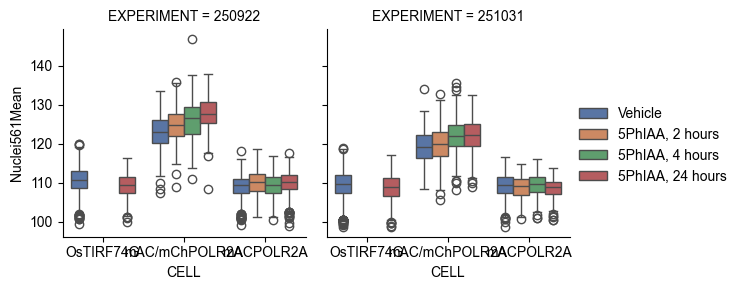

In [20]:
g = sns.FacetGrid(QuantificationMultiple,
                  col = 'EXPERIMENT')

g.map_dataframe(sns.boxplot,
                x = 'CELL', order = cell_order,
                y = 'Nuclei561Mean',
                hue = 'TREATMENT', hue_order = treatment_order,
                palette = 'deep')

g.add_legend()

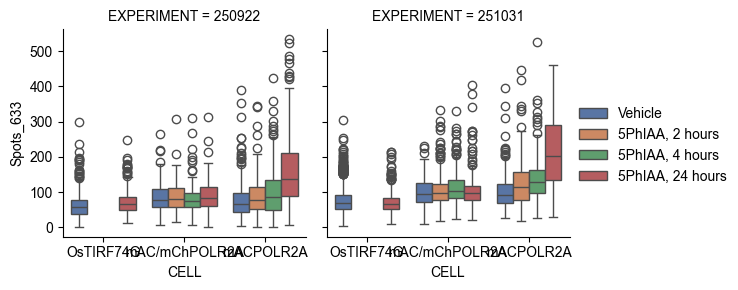

In [21]:
g = sns.FacetGrid(QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even"'),
                  col = 'EXPERIMENT')

g.map_dataframe(sns.boxplot,
                x = 'CELL', order = cell_order,
                y = 'Spots_633',
                hue = 'TREATMENT', hue_order = treatment_order,
                palette = 'deep')

g.add_legend()

## bin volumes and plot combined volume / spot count for vehicle vs 5PhIAA

In [22]:
binz = [p/100 for p in range(100,580,80)]
binz_centre = []
for i,b in enumerate(binz[:-1]):
    g = (binz[i+1] - b)
    h = b + g/2
    binz_centre.append(h)

(0.0, 8.0)

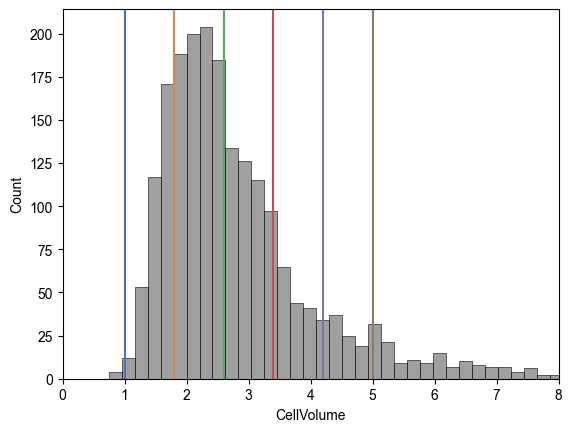

In [23]:
sns.histplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"').CellVolume,
             color = 'grey')

clrs = sns.color_palette('deep')

for i,b in enumerate(binz):
    plt.axvline(b, c = clrs[i])

plt.xlim(0,8)

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashi

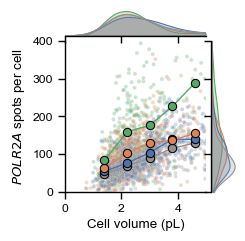

In [24]:
mAC_FOR_PLOT = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"')

MAC_VEH = mAC_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()

MAC_5_2HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 2 hours"')
MAC_5_2HR_MEAN = MAC_5_2HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_2HR.CellVolume, binz)).mean()

MAC_5_4HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 4 hours"')
MAC_5_4HR_MEAN = MAC_5_4HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_4HR.CellVolume, binz)).mean()

MAC_5_24HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_5_24HR_MEAN = MAC_5_24HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_24HR.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

sns.jointplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,400),
              height = 2.5,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_5_2HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[1])

sns.lineplot(x = binz_centre,
             y = MAC_5_4HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[2])

sns.lineplot(x = binz_centre,
             y = MAC_5_24HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[3])

plt.xlabel('Cell volume (pL)')
plt.ylabel('$POLR2A$ spots per cell')

plt.savefig('mACPOLR2A_POLR2Aspots_per_time_2repeats.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashi

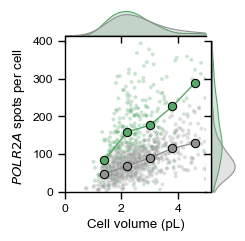

In [25]:
mAC_FOR_PLOT = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"')

MAC_VEH = mAC_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()

MAC_5_2HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 2 hours"')
MAC_5_2HR_MEAN = MAC_5_2HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_2HR.CellVolume, binz)).mean()

MAC_5_4HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 4 hours"')
MAC_5_4HR_MEAN = MAC_5_4HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_4HR.CellVolume, binz)).mean()

MAC_5_24HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_5_24HR_MEAN = MAC_5_24HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_24HR.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

sns.jointplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even" & TREATMENT in ["Vehicle", "5PhIAA, 24 hours"]'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,400),
              height = 2.5,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_5_24HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[3])

plt.xlabel('Cell volume (pL)')
plt.ylabel('$POLR2A$ spots per cell')

plt.savefig('mACPOLR2A_POLR2Aspots_veh_24_2repeats.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashi

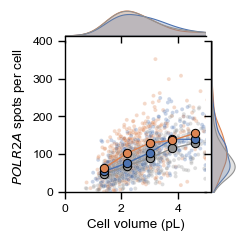

In [26]:
mAC_FOR_PLOT = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"')

MAC_VEH = mAC_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()

MAC_5_2HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 2 hours"')
MAC_5_2HR_MEAN = MAC_5_2HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_2HR.CellVolume, binz)).mean()

MAC_5_4HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 4 hours"')
MAC_5_4HR_MEAN = MAC_5_4HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_4HR.CellVolume, binz)).mean()

MAC_5_24HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_5_24HR_MEAN = MAC_5_24HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_24HR.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

sns.jointplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even" & TREATMENT in ["Vehicle","5PhIAA, 2 hours","5PhIAA, 4 hours"]'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,400),
              height = 2.5,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_5_2HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[1])

sns.lineplot(x = binz_centre,
             y = MAC_5_4HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[2])


plt.xlabel('Cell volume (pL)')
plt.ylabel('$POLR2A$ spots per cell')

plt.savefig('mACPOLR2A_POLR2Aspots_0_2_4hrs_2repeats.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:17

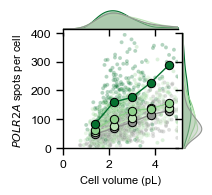

In [27]:
mAC_FOR_PLOT = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"')

MAC_VEH = mAC_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()

MAC_5_2HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 2 hours"')
MAC_5_2HR_MEAN = MAC_5_2HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_2HR.CellVolume, binz)).mean()

MAC_5_4HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 4 hours"')
MAC_5_4HR_MEAN = MAC_5_4HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_4HR.CellVolume, binz)).mean()

MAC_5_24HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_5_24HR_MEAN = MAC_5_24HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_24HR.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette(['xkcd:grey',sns.color_palette('Greens')[1],sns.color_palette('Greens')[2],sns.color_palette('Greens')[5]])

sns.jointplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,400),
              height = 1.8,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_5_2HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[1])

sns.lineplot(x = binz_centre,
             y = MAC_5_4HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[2])

sns.lineplot(x = binz_centre,
             y = MAC_5_24HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[3])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2A$ spots per cell', fontsize = 8)

plt.savefig('mACPOLR2A_POLR2Aspots_per_time_2repeats_greens.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:17

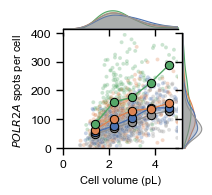

In [28]:
mAC_FOR_PLOT = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"')

MAC_VEH = mAC_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()

MAC_5_2HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 2 hours"')
MAC_5_2HR_MEAN = MAC_5_2HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_2HR.CellVolume, binz)).mean()

MAC_5_4HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 4 hours"')
MAC_5_4HR_MEAN = MAC_5_4HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_4HR.CellVolume, binz)).mean()

MAC_5_24HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_5_24HR_MEAN = MAC_5_24HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_24HR.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

sns.jointplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE == "POLR2A even"'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,400),
              height = 1.8,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_5_2HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[1])

sns.lineplot(x = binz_centre,
             y = MAC_5_4HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[2])

sns.lineplot(x = binz_centre,
             y = MAC_5_24HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[3])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2A$ spots per cell', fontsize = 8)

plt.savefig('mACPOLR2A_POLR2Aspots_per_time_2repeats.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:17

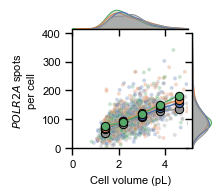

In [29]:
mACmCh_FOR_PLOT = QuantificationMultiple.query('CELL == "mAC/mChPOLR2A" & ATTO633_PROBE == "POLR2A even"')

MAC_MCH_VEH = mACmCh_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_MCH_VEH_MEAN = MAC_MCH_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_MCH_VEH.CellVolume, binz)).mean()

MAC_MCH_5_2HR = mACmCh_FOR_PLOT.query('TREATMENT == "5PhIAA, 2 hours"')
MAC_MCH_5_2HR_MEAN = MAC_MCH_5_2HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_MCH_5_2HR.CellVolume, binz)).mean()

MAC_MCH_5_4HR = mACmCh_FOR_PLOT.query('TREATMENT == "5PhIAA, 4 hours"')
MAC_MCH_5_4HR_MEAN = MAC_MCH_5_4HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_MCH_5_4HR.CellVolume, binz)).mean()

MAC_MCH_5_24HR = mACmCh_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_MCH_5_24HR_MEAN = MAC_MCH_5_24HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_MCH_5_24HR.CellVolume, binz)).mean()

sns.set_context('paper')

pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

sns.jointplot(QuantificationMultiple.query('CELL == "mAC/mChPOLR2A" & ATTO633_PROBE == "POLR2A even"'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,400),
              height = 1.8,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_MCH_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_MCH_5_2HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[1])

sns.lineplot(x = binz_centre,
             y = MAC_MCH_5_4HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[2])

sns.lineplot(x = binz_centre,
             y = MAC_MCH_5_24HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[3])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2A$ spots\nper cell', fontsize = 8)

plt.tick_params(axis = 'both', labelsize = 8)


plt.savefig('mACmChPOLR2A_POLR2Aspots_per_time_2repeats.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site

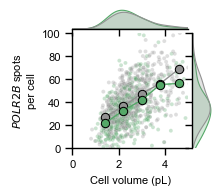

In [30]:
mAC_FOR_PLOT = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE in ["POLR2B even", "POLR2B odd"]')

MAC_VEH = mAC_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_633']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()

MAC_5_24HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_5_24HR_MEAN = MAC_5_24HR[['CellVolume','Spots_633']].groupby(pd.cut(MAC_5_24HR.CellVolume, binz)).mean()


sns.set_context('paper')

pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

sns.jointplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE in ["POLR2B even", "POLR2B odd"]'),
              x = 'CellVolume',
              y = 'Spots_633',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,100),
              height = 1.8,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_5_24HR_MEAN.Spots_633,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[3])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2B$ spots\nper cell', fontsize = 8)

plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('mACPOLR2A_POLR2Bspots_2repeats.svg')

/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/alexandergillis/opt/anaconda3/envs/berrylab-py310/lib/python3.10/site

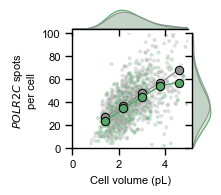

In [31]:
mAC_FOR_PLOT = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO565_PROBE == "POLR2C"')

MAC_VEH = mAC_FOR_PLOT.query('TREATMENT == "Vehicle"')
MAC_VEH_MEAN = MAC_VEH[['CellVolume','Spots_565']].groupby(pd.cut(MAC_VEH.CellVolume, binz)).mean()

MAC_5_24HR = mAC_FOR_PLOT.query('TREATMENT == "5PhIAA, 24 hours"')
MAC_5_24HR_MEAN = MAC_5_24HR[['CellVolume','Spots_565']].groupby(pd.cut(MAC_5_24HR.CellVolume, binz)).mean()


sns.set_context('paper')

pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

sns.jointplot(QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO565_PROBE == "POLR2C"'),
              x = 'CellVolume',
              y = 'Spots_565',
              hue = 'TREATMENT', hue_order = ['Vehicle','5PhIAA, 2 hours','5PhIAA, 4 hours','5PhIAA, 24 hours'],
              palette = pal,
              marginal_kws=dict(common_norm = False),
              xlim = (0,5),
              ylim = (0,100),
              height = 1.8,
              legend = False,
              s = 8,
              joint_kws = {'alpha' : 0.3})

sns.lineplot(x = binz_centre,
             y = MAC_VEH_MEAN.Spots_565,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[0])

sns.lineplot(x = binz_centre,
             y = MAC_5_24HR_MEAN.Spots_565,
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             linewidth = 1,
             color = pal[3])

plt.xlabel('Cell volume (pL)', fontsize = 8)
plt.ylabel('$POLR2C$ spots\nper cell', fontsize = 8)

plt.tick_params(axis = 'both', labelsize = 8)

plt.savefig('mACPOLR2A_POLR2Cspots_2repeats.svg')

## convert to spots per pL and plot over time

In [32]:
MAC_SPOTS_TIMEPLOT = QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even" & CELL == "mACPOLR2A"')
MAC_SPOTS_TIMEPLOT['TIME'] = MAC_SPOTS_TIMEPLOT.TREATMENT.map(dict(zip(['Vehicle', '5PhIAA, 2 hours', '5PhIAA, 4 hours', '5PhIAA, 24 hours'],[0,2,4,24])))

MACMCH_SPOTS_TIMEPLOT = QuantificationMultiple.query('ATTO633_PROBE == "POLR2A even" & CELL == "mAC/mChPOLR2A"')
MACMCH_SPOTS_TIMEPLOT['TIME'] = MACMCH_SPOTS_TIMEPLOT.TREATMENT.map(dict(zip(['Vehicle', '5PhIAA, 2 hours', '5PhIAA, 4 hours', '5PhIAA, 24 hours'],[0,2,4,24])))

MAC_SPOTS_TIMEPLOT['SPOTS_PER_VOLUME'] = MAC_SPOTS_TIMEPLOT['Spots_633'] / MAC_SPOTS_TIMEPLOT['CellVolume']
MACMCH_SPOTS_TIMEPLOT['SPOTS_PER_VOLUME'] = MACMCH_SPOTS_TIMEPLOT['Spots_633'] / MACMCH_SPOTS_TIMEPLOT['CellVolume']

MAC_SPOTS_TIMEPLOT['REPLICATE'] = MAC_SPOTS_TIMEPLOT.EXPERIMENT.map(dict(zip(['250922', '251031'], ['Replicate 1','Replicate 2'])))
MACMCH_SPOTS_TIMEPLOT['REPLICATE'] = MACMCH_SPOTS_TIMEPLOT.EXPERIMENT.map(dict(zip(['250922', '251031'], ['Replicate 1','Replicate 2'])))

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_88268/2418056422.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MAC_SPOTS_TIMEPLOT['TIME'] = MAC_SPOTS_TIMEPLOT.TREATMENT.map(dict(zip(['Vehicle', '5PhIAA, 2 hours', '5PhIAA, 4 hours', '5PhIAA, 24 hours'],[0,2,4,24])))
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_88268/2418056422.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MACMCH_SPOTS_TIMEPLOT['TIME'] = MACMCH_SPOTS_TIMEPLOT.TREATMENT.map(dict(zip(['Vehicle', '5PhIAA, 2 h

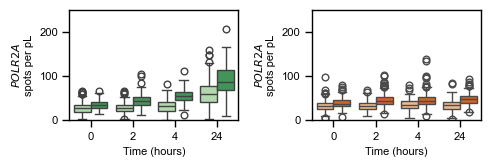

In [33]:
f, a = plt.subplots(ncols = 2, figsize = (5,1.8))

b = sns.boxplot(MAC_SPOTS_TIMEPLOT,
            x = 'TIME',
            y = 'SPOTS_PER_VOLUME',
            hue = 'REPLICATE', dodge = True, palette = 'Greens',
            ax = a[0])
b.legend().remove()

b = sns.boxplot(MACMCH_SPOTS_TIMEPLOT,
            x = 'TIME',
            y = 'SPOTS_PER_VOLUME',
            hue = 'REPLICATE', dodge = True, palette = 'Oranges',
            ax = a[1])
b.legend().remove()

a[0].set_ylabel('$POLR2A$\nspots per pL', fontsize = 8)
a[1].set_ylabel('$POLR2A$\nspots per pL', fontsize = 8)

for i in range(2):
    a[i].set_ylim(0,250)
    a[i].set_xlabel('Time (hours)', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)

plt.tight_layout()

plt.savefig('mAC_mACmCh_5Ph_timecourse_per_replicate.svg')

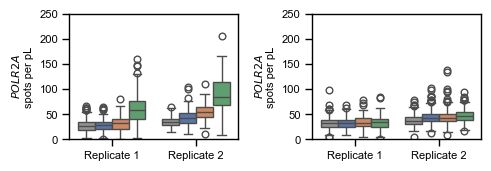

In [34]:
f, a = plt.subplots(ncols = 2, figsize = (5,1.8))


pal = sns.color_palette([sns.color_palette('grey')[3]] + sns.color_palette('deep')[:3])

b = sns.boxplot(MAC_SPOTS_TIMEPLOT,
            x = 'REPLICATE',
            y = 'SPOTS_PER_VOLUME',
            hue = 'TIME', dodge = True, palette = pal,
            ax = a[0])
b.legend().remove()

b = sns.boxplot(MACMCH_SPOTS_TIMEPLOT,
            x = 'REPLICATE',
            y = 'SPOTS_PER_VOLUME',
            hue = 'TIME', dodge = True, palette = pal,
            ax = a[1])
b.legend().remove()

a[0].set_ylabel('$POLR2A$\nspots per pL', fontsize = 8)
a[1].set_ylabel('$POLR2A$\nspots per pL', fontsize = 8)

for i in range(2):
    a[i].set_ylim(0,250)
    a[i].set_xlabel('', fontsize = 8)
    a[i].tick_params(axis = 'both', labelsize = 8)

plt.tight_layout()

plt.savefig('mAC_mACmCh_5Ph_timecourse_per_replicate.svg')

In [35]:
MAC_SPOTS_POLR2B_PER_VOLUME = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO633_PROBE in ["POLR2B even", "POLR2B odd"]')
MAC_SPOTS_POLR2B_PER_VOLUME['SPOTS_PER_VOLUME'] = MAC_SPOTS_POLR2B_PER_VOLUME['Spots_633'] / MAC_SPOTS_POLR2B_PER_VOLUME['CellVolume']
MAC_SPOTS_POLR2B_PER_VOLUME['REPLICATE'] = MAC_SPOTS_POLR2B_PER_VOLUME.EXPERIMENT.map(dict(zip(['250922', '251031'], ['Replicate 1','Replicate 2'])))

MAC_SPOTS_POLR2C_PER_VOLUME = QuantificationMultiple.query('CELL == "mACPOLR2A" & ATTO565_PROBE == "POLR2C"')
MAC_SPOTS_POLR2C_PER_VOLUME['SPOTS_PER_VOLUME'] = MAC_SPOTS_POLR2C_PER_VOLUME['Spots_565'] / MAC_SPOTS_POLR2C_PER_VOLUME['CellVolume']
MAC_SPOTS_POLR2C_PER_VOLUME['REPLICATE'] = MAC_SPOTS_POLR2C_PER_VOLUME.EXPERIMENT.map(dict(zip(['250922', '251031'], ['Replicate 1','Replicate 2'])))

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_88268/468996302.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MAC_SPOTS_POLR2B_PER_VOLUME['SPOTS_PER_VOLUME'] = MAC_SPOTS_POLR2B_PER_VOLUME['Spots_633'] / MAC_SPOTS_POLR2B_PER_VOLUME['CellVolume']
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_88268/468996302.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MAC_SPOTS_POLR2B_PER_VOLUME['REPLICATE'] = MAC_SPOTS_POLR2B_PER_VOLUME.EXPERIMENT.map(dict(zip(['250922', '251031'], ['Repl

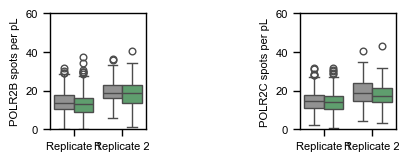

In [36]:
f, a = plt.subplots(ncols = 2, figsize = (5,1.5), layout = 'constrained')

pal = sns.color_palette([sns.color_palette('grey')[3], sns.color_palette('deep')[2]])

b = sns.boxplot(MAC_SPOTS_POLR2B_PER_VOLUME,
            x = 'REPLICATE',
            y = 'SPOTS_PER_VOLUME',
            hue = 'TREATMENT', dodge = True, palette = pal,
            ax = a[0])
b.legend().remove()

b = sns.boxplot(MAC_SPOTS_POLR2C_PER_VOLUME,
            x = 'REPLICATE',
            y = 'SPOTS_PER_VOLUME',
            hue = 'TREATMENT', dodge = True, palette = pal,
            ax = a[1])
b.legend().remove()

a[0].set_ylabel('POLR2B spots per pL', fontsize = 8)
a[1].set_ylabel('POLR2C spots per pL', fontsize = 8)

for i in range(2):
    a[i].set_ylim(0,60)
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_box_aspect(1.2)
    a[i].tick_params(axis = 'both', labelsize = 8)

plt.savefig('mAC_POLR2B_2C_5Ph_per_replicate.svg')

### load total Pol II IF data for comparison of mRNA to protein levels

In [37]:
mACPOLR2A_By_Replicate = MAC_SPOTS_TIMEPLOT[['REPLICATE', 'TIME', 'SPOTS_PER_VOLUME']].groupby(['REPLICATE', 'TIME']).mean().reset_index()

mACmCherryPOLR2A_By_Replicate = MACMCH_SPOTS_TIMEPLOT[['REPLICATE', 'TIME', 'SPOTS_PER_VOLUME']].groupby(['REPLICATE', 'TIME']).mean().reset_index()

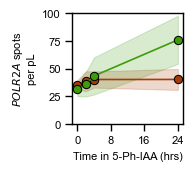

In [38]:
sns.set_context('paper')

f, a = plt.subplots( ncols = 1, figsize = (3,1.6), layout = 'constrained')


sns.lineplot(mACmCherryPOLR2A_By_Replicate,
             x = 'TIME',
             y = 'SPOTS_PER_VOLUME',
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:rust',
             errorbar = 'sd',
             ax = a)

sns.lineplot(mACPOLR2A_By_Replicate,
             x = 'TIME',
             y = 'SPOTS_PER_VOLUME',
             marker = 'o', markersize = 6, markeredgecolor = 'black',
             color = 'xkcd:grass green',
             errorbar = 'sd',
             ax = a)



a.set_box_aspect(1)

a.set_xticks(range(0,25,8))

a.set_xlabel('Time in 5-Ph-IAA (hrs)', fontsize = 8)

a.set_ylabel('$POLR2A$ spots\nper pL', fontsize = 8)

a.set_ylim(0,100)
a.set_yticks([0, 25, 50, 75, 100])

a.tick_params('x', labelsize = 8)
a.tick_params('y', labelsize = 8)

In [39]:
mACPOLR2A_By_Replicate['CELL'] = "mACPOLR2A"
mACmCherryPOLR2A_By_Replicate['CELL'] = "mACmChPOLR2A"

In [40]:
Timecourse_By_Replicate = pd.concat([mACPOLR2A_By_Replicate,mACmCherryPOLR2A_By_Replicate])

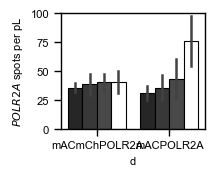

In [41]:
sns.set_context('paper')

f, a = plt.subplots( ncols = 1, figsize = (3,1.65), layout = 'constrained')

h = sns.barplot(Timecourse_By_Replicate,
                x = 'CELL', order = ["mACmChPOLR2A", "mACPOLR2A"],
                hue = 'TIME',
                edgecolor = 'black',
                color = 'white',
                dodge = True,
                y = 'SPOTS_PER_VOLUME',
                errorbar = 'sd')

h.get_legend().remove()

a.set_box_aspect(0.8)

a.set_xlabel('d', fontsize = 8)

a.set_ylabel('$POLR2A$ spots per pL', fontsize = 8)

a.set_ylim(0,100)
a.set_yticks([0, 25, 50, 75, 100])

a.tick_params('x', labelsize = 8)
a.tick_params('y', labelsize = 8)

plt.savefig('macmch_mac_polr2a_spots_per_time_barplot.svg')

In [45]:
mACPOLR2A_By_Replicate = Timecourse_By_Replicate.query('CELL == "mACPOLR2A"')

In [58]:
mACPOLR2A_By_Replicate

,REPLICATE,TIME,SPOTS_PER_VOLUME,CELL
0,Replicate 1,0,26.944146,mACPOLR2A
1,Replicate 1,2,27.970733,mACPOLR2A
2,Replicate 1,4,31.556706,mACPOLR2A
3,Replicate 1,24,60.594769,mACPOLR2A
4,Replicate 2,0,35.553331,mACPOLR2A
5,Replicate 2,2,43.556141,mACPOLR2A
6,Replicate 2,4,55.263918,mACPOLR2A
7,Replicate 2,24,91.407910,mACPOLR2A


In [56]:
nvs = []
rps = []

for r in mACPOLR2A_By_Replicate.REPLICATE.unique():
    norm_val = mACPOLR2A_By_Replicate.query('REPLICATE == @r & TIME == 0').SPOTS_PER_VOLUME.values[0]
    nvs.append(norm_val)
    rps.append(r)
    
NormalisationValues = dict(zip(rps,nvs))

In [61]:
mACPOLR2A_By_Replicate['NormalisationValue'] = mACPOLR2A_By_Replicate.REPLICATE.map(NormalisationValues)
mACPOLR2A_By_Replicate['SPOTS_PER_VOLUME_FOLDCHANGE'] = mACPOLR2A_By_Replicate['SPOTS_PER_VOLUME'] / mACPOLR2A_By_Replicate['NormalisationValue']

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_88268/2080531096.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACPOLR2A_By_Replicate['NormalisationValue'] = mACPOLR2A_By_Replicate.REPLICATE.map(NormalisationValues)
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_88268/2080531096.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mACPOLR2A_By_Replicate['SPOTS_PER_VOLUME_FOLDCHANGE'] = mACPOLR2A_By_Replicate['SPOTS_PER_VOLUME'] / mACPOLR2A_By_Replicate['NormalisationValue']


In [64]:
mACPOLR2A_By_Replicate[['TIME','CELL','SPOTS_PER_VOLUME_FOLDCHANGE']].groupby(['TIME','CELL']).std()

,,SPOTS_PER_VOLUME_FOLDCHANGE
TIME,CELL,
0,mACPOLR2A,0.000000
2,mACPOLR2A,0.132224
4,mACPOLR2A,0.270967
24,mACPOLR2A,0.227763


In [44]:
Timecourse_By_Replicate[['CELL','TIME','SPOTS_PER_VOLUME']].groupby(['CELL','TIME']).mean().reset_index()

,CELL,TIME,SPOTS_PER_VOLUME
0,mACPOLR2A,0,31.248738
1,mACPOLR2A,2,35.763437
2,mACPOLR2A,4,43.410312
3,mACPOLR2A,24,76.001340
4,mACmChPOLR2A,0,35.569223
5,mACmChPOLR2A,2,38.570632
6,mACmChPOLR2A,4,40.161702
7,mACmChPOLR2A,24,40.216202
